## Notebook Setup

In [125]:
!where python 

d:\Fiap\Github\python-pj\iris-classification\.venv\Scripts\python.exe
C:\Users\the5l\AppData\Local\hermes\hermes-agent\venv\Scripts\python.exe
C:\Users\the5l\AppData\Local\Programs\Python\Python313\python.exe
C:\Users\the5l\AppData\Local\Microsoft\WindowsApps\python.exe


In [126]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [127]:
# Standart imports
import os

# Third-party imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

# Local imports

In [128]:
sns.set() 

In [129]:
# Load data
data = datasets.load_iris(as_frame=True)

In [130]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [131]:
data['data'][:5]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [132]:
data['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [133]:
data['target']

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [134]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
# Create a DataFrame from the data

df = pd.DataFrame(data['data'], columns=data['feature_names'])
df['target'] = data['target']

In [136]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


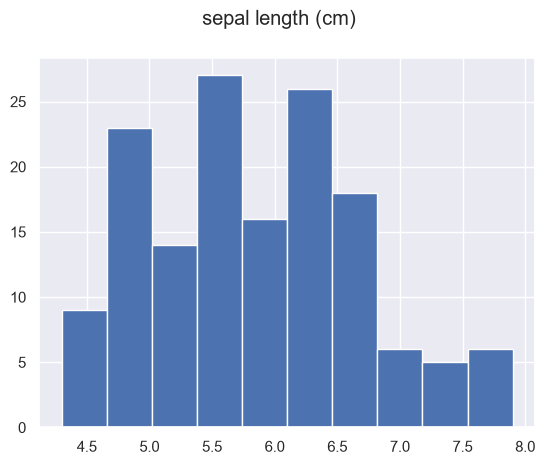

In [137]:
# Visualize the distribution of a feature

col = 'sepal length (cm)'
df[col].hist()
plt.suptitle(col)
plt.show()

In [ ]:
# Create a new column with the species name

df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

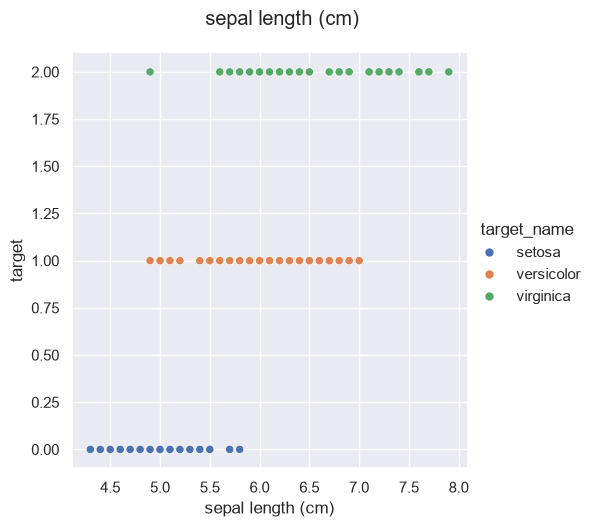

In [ ]:
# Visualize the relationship between a feature and the target variable

col = 'sepal length (cm)'
sns.relplot(x=col, y='target', hue='target_name', data=df)
plt.suptitle(col, y=1.05)
plt.show()

# Exploratory Data Analysis (EDA) - Pairplots

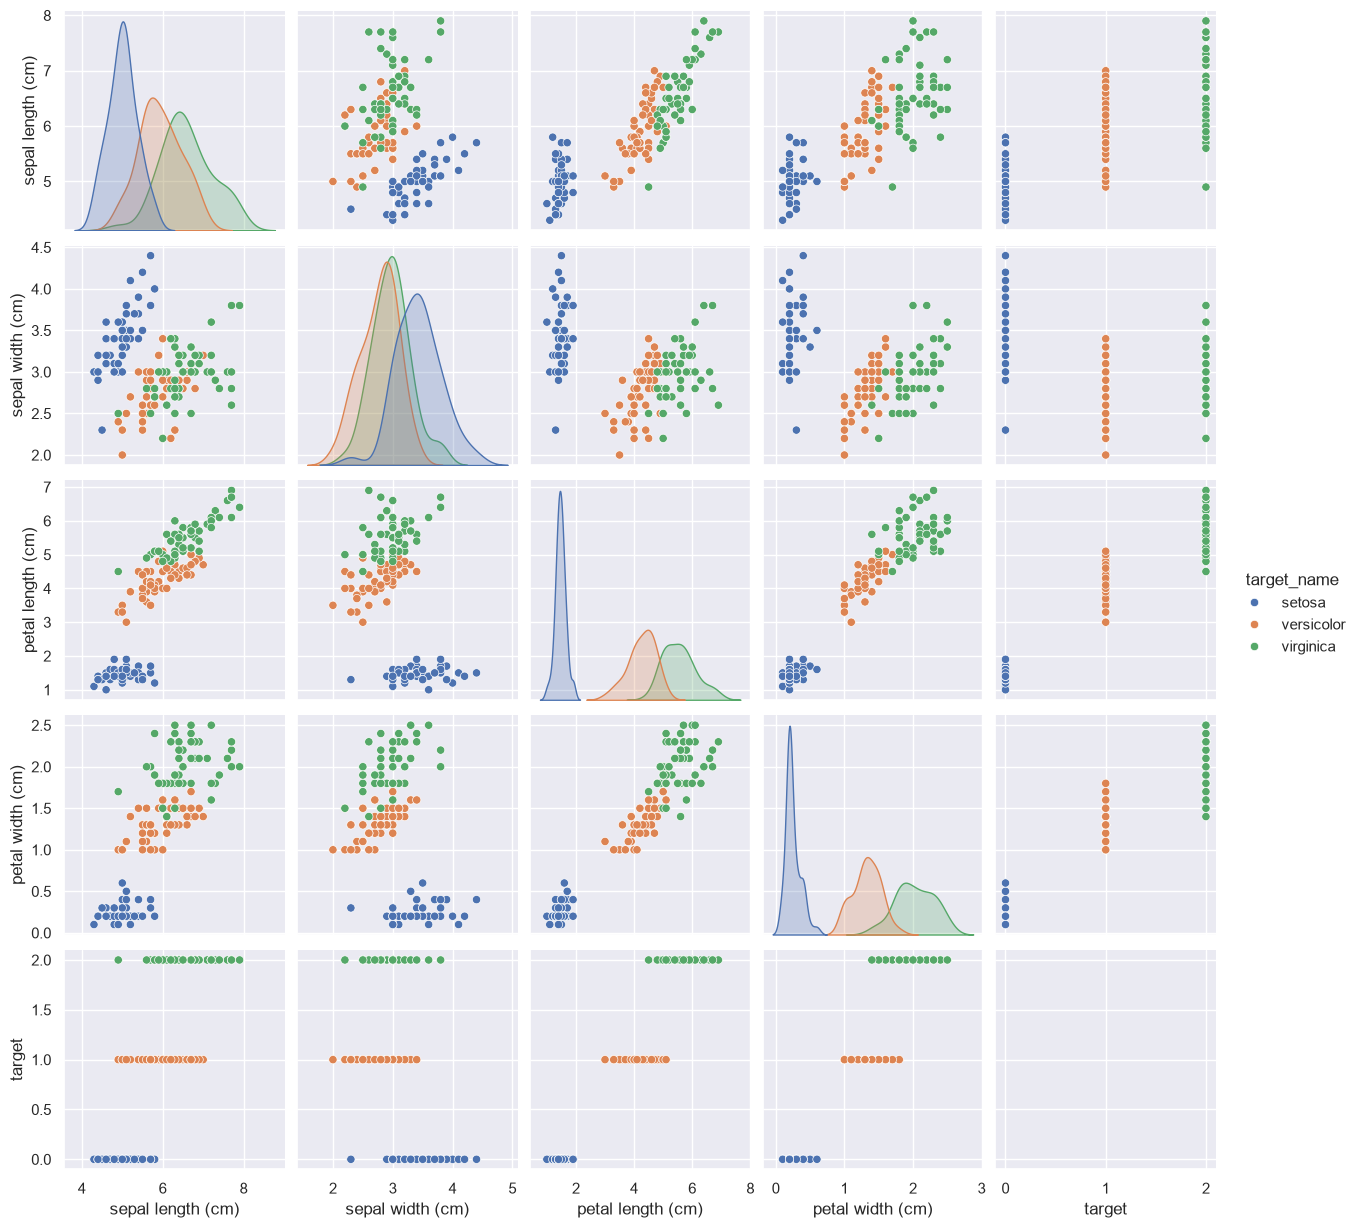

In [ ]:
# Visualize the relationship between all features

sns.pairplot(df, hue='target_name')

# Train Test Split

In [141]:
from sklearn.model_selection import train_test_split

In [142]:
df_train, df_test = train_test_split(df, test_size=0.25)

# Preparing our data for modeling

In [ ]:
# We are getting just the features, so we drop the target and target_name columns

X_train = df_train.drop(columns=['target', 'target_name']).values
y_train = df_train['target'].values

# Modeling - Simple manual model

In [ ]:
# Predicting the species based on a single feature (petal length)

def single_feature_prediction(petal_length):
    if petal_length < 2.5:
        return 0
    elif petal_length < 4.8:
        return 1
    else:
        return 2

In [145]:
X_train[:, 2]

array([3.6, 4.9, 4.4, 4.1, 3.9, 5.3, 4.5, 4.9, 4.7, 5.7, 3.3, 1.5, 5.3,
       5.5, 4.5, 1.4, 1.6, 1.5, 4.8, 4.9, 5.9, 1.4, 5.6, 5.5, 6.1, 4.4,
       4.3, 4.5, 1.5, 3. , 1.5, 4. , 1.5, 5. , 6. , 4.2, 1.6, 1.4, 3.9,
       1.5, 4.1, 1.7, 1.4, 3.7, 5.6, 5.7, 1.1, 1. , 5. , 5.1, 3.9, 5.1,
       1.3, 5.8, 1.5, 4.5, 4.5, 4. , 3.3, 5.4, 6. , 1.9, 4.1, 6.3, 1.4,
       4.7, 1.4, 4.2, 5.1, 4.2, 4. , 5.1, 3.5, 1.6, 4.7, 1.4, 1.4, 3.8,
       1.3, 5.8, 1.6, 1.4, 5.6, 4.6, 1.5, 5. , 4. , 3.5, 1.6, 1.7, 4.9,
       6.6, 1.2, 1.5, 1.6, 5.7, 1.7, 4.5, 1.5, 5.6, 1.4, 5.6, 5.8, 1.3,
       4.5, 5. , 1.5, 5.1, 5.2, 6.7, 1.4, 1.5])

In [ ]:
# Make predictions using the manual rule-based approach

manual_y_predictions = np.array([single_feature_prediction(val) for val in X_train[:, 2]])

In [147]:
manual_model_accuracy = np.mean(manual_y_predictions == y_train)

In [148]:
print(f'Manual model accuracy: {manual_model_accuracy:.2%}')

Manual model accuracy: 95.54%


# Modeling - Logistic Regression

In [149]:
from sklearn.linear_model import LogisticRegression

## Using validation set to evaluate our model

In [150]:
model = LogisticRegression(max_iter=200)

In [151]:
# Xt stands for "X_train", Xv stands for "X_validation", yt stands for "y_train", and yv stands for "y_validation"
Xt, Xv, yt, yv = train_test_split(X_train, y_train, test_size=0.25)

In [152]:
Xt.shape

(84, 4)

In [153]:
Xv.shape

(28, 4)

In [154]:
model.fit(Xt, yt)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [155]:
y_pred = model.predict(Xv)

In [156]:
print(np.mean(y_pred == yv))
# Or
model.score(Xv, yv)

0.9642857142857143


0.9642857142857143

# Using cross-validation to evaluate or model

In [157]:
from sklearn.model_selection import cross_val_score, cross_val_predict

In [158]:
model = LogisticRegression(max_iter=200)

In [159]:
accuracies = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

In [160]:
print(np.mean(accuracies))

0.9731225296442687


# Where are we misclassifying points?

In [161]:
y_pred = cross_val_predict(model, X_train, y_train, cv=5)

In [162]:
predicted_correctly_mask = y_pred == y_train

In [163]:
predicted_correctly_mask

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [164]:
not_predicted_correctly_mask = ~predicted_correctly_mask

In [165]:
X_train[not_predicted_correctly_mask]

array([[6. , 2.2, 5. , 1.5],
       [6.7, 3. , 5. , 1.7],
       [4.9, 2.5, 4.5, 1.7]])

In [166]:
df_predictions = df_train.copy()

In [167]:
df_predictions['correct_prediction'] = predicted_correctly_mask

In [168]:
df_predictions['prediction'] = y_pred

In [169]:
df_predictions['prediction_label'] = df_predictions['prediction'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

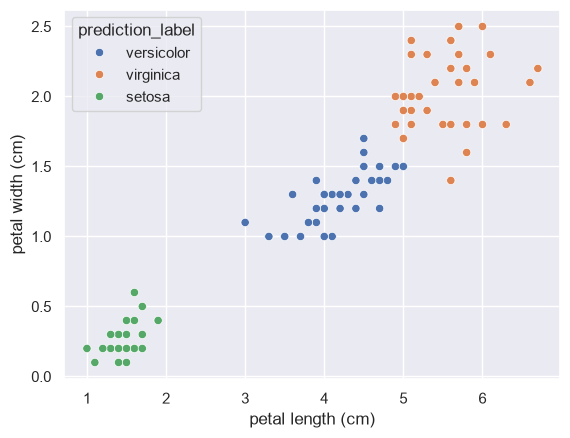

In [170]:
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='prediction_label', data=df_predictions)

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

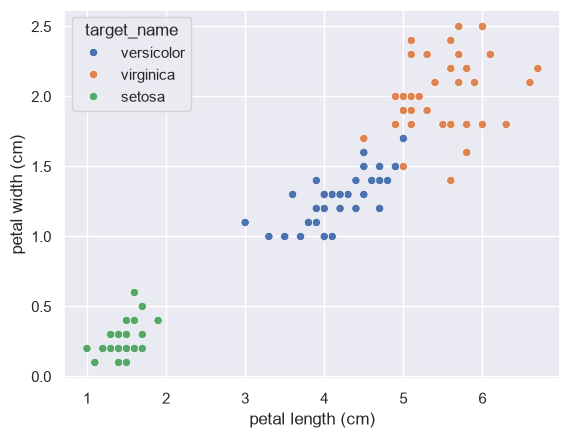

In [171]:
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='target_name', data=df_predictions)

In [172]:
def incorrect_predictions(df_predictions, x_axis_feature, y_axis_feature):
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    axs= axs.flatten()
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue='prediction_label', data=df_predictions, ax=axs[0])
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue='target_name', data=df_predictions, ax=axs[1])
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue='correct_prediction', data=df_predictions, ax=axs[2])
    axs[3].set_visible(False)

    plt.show()

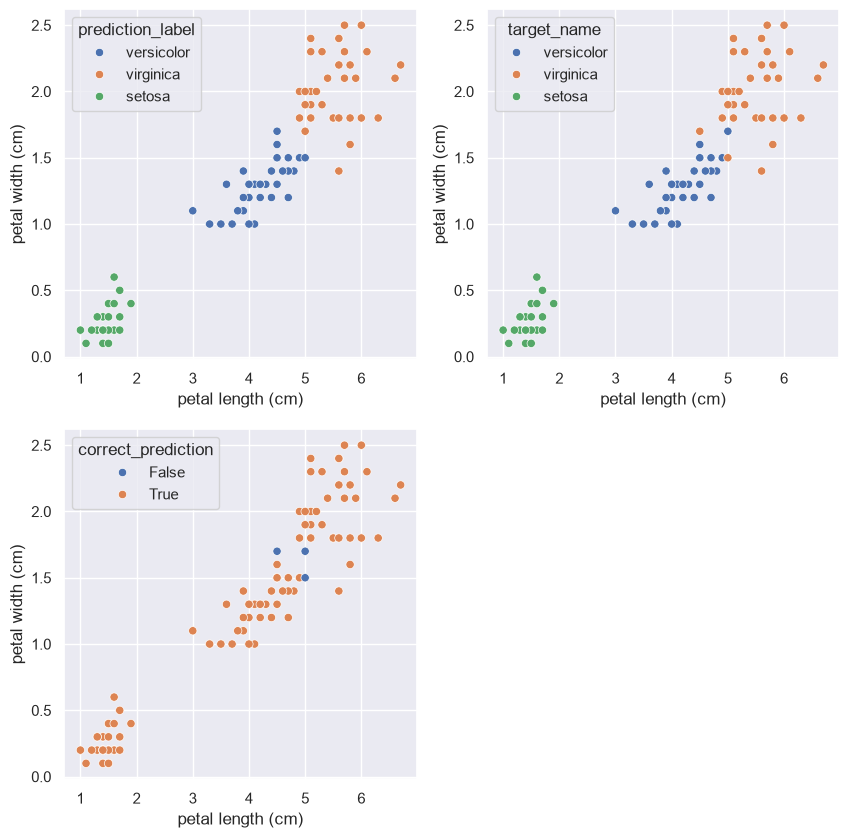

In [173]:
incorrect_predictions(df_predictions, 'petal length (cm)', 'petal width (cm)')

# Model Tunning

Simple model Tunning:

In [ ]:
# Find the best regularization parameter

for reg_param in [1.8, 1.9, 2, 2.1, 2.5]:
    model = LogisticRegression(max_iter=200, C=reg_param)
    accuracies = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f'Mean accuracy for C={reg_param}: {np.mean(accuracies):.2%}')

Mean accuracy for C=1.8: 97.31%
Mean accuracy for C=1.9: 97.31%
Mean accuracy for C=2: 97.31%
Mean accuracy for C=2.1: 97.31%
Mean accuracy for C=2.5: 97.31%


# Final Model

In [175]:
model = LogisticRegression(max_iter=200, C=2)

In [176]:
X_test = df_test.drop(columns=['target', 'target_name']).values
y_test = df_test['target'].values

In [177]:
X_test.shape

(38, 4)

### Train our final model using our full Training Dataset

In [178]:
model.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [179]:
y_test_pred = model.predict(X_test)

In [180]:
print(f'Test set accuracy: {np.mean(y_test_pred == y_test):.2%}')

Test set accuracy: 94.74%


# In Conclusion

We achived a 94.74% accuracy on the test dataset using a Logistic Regression model!!
